# 061 — Design-group MSA-FEMAP695 collapse fragilities

Collects the **MSA-FEMAP695** collapse fragility of every design group from the analysis
drive, copies it into the processed-data tree **with a provenance manifest**, plots it
against its stripe IMLs, reports which curves are *not well defined*, and then **fans
each group's fragility back out to every member site**.

This is notebook `060` done per **design group** instead of per site, with `053`'s
fan-out bolted on the end:

| arm | records | run per | processed by |
|---|---|---|---|
| MSA | 30 GCIM records, different at every stripe and site | site | `060` |
| IDA (`ida_femap695`) | 22 FEMA P695 records, hunt-trace-fill | design group | `053` |
| **MSA-FEMAP695** | 22 FEMA P695 records, the same at every stripe | design group | **this notebook** |

Notebook `051` showed the 120 (site, storey) designs collapse to **51 unique designs**
(25 × 3s, 26 × 5s). Because the FEMA P695 record set does not depend on the site, the
MSA-FEMAP695 analysis depends only on the structure, so `054` runs it once per group at
`D:/08_wp1_fixed_record_sets/group_{n}s_{gid}/{n}s/mdof/msa_AvgSA_03_femap695/`.

## Inputs

- `{GROUP_ROOT}/group_{n}s_{gid}/{n}s/mdof/msa_AvgSA_03_femap695/collapse_fragility.json`
  — the MSA run output (`median`, `dispersion`, and the 2×N empirical curve `efc`), `054`.
- `unique_structural_designs.csv` (nb `051`) — the (site, storey) → group table.
- `results/04_record_selection/AvgSA_03_FEMAP695/group_folder_map.csv` (nb `054`) —
  cross-checked, not required.
- `ec8_gen2_site_specific_cbfs.pickle` (nb `011`) — the structure tag of each site, which
  is what the per-site filenames are built from.

## Outputs

| Path | Content |
|---|---|
| `…/09_structure_fragility_curves/wp1_design_groups/group_{n}s_{gid}/group_{n}s_{gid}_msa_femap695_collapsefragility_AvgSA_03.json` | the group fragility (+ manifest) |
| `…/09_structure_fragility_curves/wp1_casestudy_sites/site_{ii}/{tag}_msa_femap695_collapsefragility_AvgSA_03.json` | the per-site copy (+ manifest) |
| `…/wp1_design_groups/group_msa_femap695_collapsefragility_summary.csv` | group-level table |
| `…/wp1_casestudy_sites/site_msa_femap695_collapsefragility_summary.csv` | site-level table |
| `…/wp1_design_groups/group_msa_femap695_additional_stripes.csv` | the extra stripes §4 asks for, read back by `054` |
| `results/07_group_msa_femap695/fragility_curves_group_{n}s_{gid}.jpg` | one fragility figure per group |

The per-site filenames follow the `{tag}_{arm}_collapsefragility_AvgSA_03.json`
convention `060` (`msa`) and `014`/`053` (`ida_femap695`) already use, with the new arm
token `msa_femap695`. `069` reads only the first two suffixes, so the files written here
are inert to it until its loader learns the third arm — a separate job.

## Units

**No gravity rescale here.** `053` divides the IDA collapse IMLs by `GRAVITY` because the
IDA works in mm/s²; `054`'s stripes are built from a fragility median already in **g**, so
`cond_iml`, the fitted median and `efc[0]` are all in g and the fragility is copied
verbatim — exactly as `060` copies the site-specific MSA.

## Caching

Each group is cached against the **content hash of its source `collapse_fragility.json`**,
via `cache_utils.json_load_or_compute`. The analysed IMLs live inside that file as
`efc[0]`, so its hash already pins which stripes the curve was fitted to. The per-site
copies fingerprint the **group** fragility JSON instead — a site file is stale exactly
when its group's fragility changed. Set `FORCE_RECOMPUTE = True` to rebuild everything.

> **Run order.** `011` → `051` → `054` (+ the MSA runs) → **061** → `069`.
> The MSA results live on `D:` — run this on the machine with the drive attached. Without
> it the notebook prints a warning and falls back to the group copies already in
> `data_processed/09_…/wp1_design_groups`, so the report, the plots and the fan-out still
> work, but no group fragility is (re)written.

## Open questions, and the assumption taken for each

| # | Question | Assumption taken | If it is wrong |
|---|---|---|---|
| 1 | Per-**group** or per-**site** files? | **Both.** The group file is the cached artefact; it is then copied to every member site, so anything downstream keeps working on per-site paths. | `FANOUT_TO_SITES = False` writes only the group files. |
| 2 | What is the new arm called on disk? | **`msa_femap695`**, i.e. `{tag}_msa_femap695_collapsefragility_AvgSA_03.json`, alongside the existing `msa` and `ida_femap695` files. | Edit `MSA_TAG`. |
| 3 | Should a badly conditioned group be withheld from the fan-out? | **No.** §4 reports which groups' stripes fail to bracket collapse and both summary CSVs carry the flag, but every group is fanned out. | Filter `group_results` on `well_defined` before §5. |
| 3b | Does a **degenerate** stripe — 0 or 22 of the 22 records collapsed — satisfy a tail? | **No.** It bounds the collapse crossing without locating it, so a tail is reached only by a stripe strictly inside (0, 0.2) or (0.8, 1); §4 asks for another IML instead. A degenerate stripe alongside an informative one is harmless. | Revert `needs_low` / `needs_high` in §4 to the `pc.min()` / `pc.max()` range test. |
| 4 | How is a badly conditioned group remediated? | §4 writes the IML each failing tail needs to `group_msa_femap695_additional_stripes.csv`, aimed at **P[C] = 0.15 / 0.85** so the new stripe clears the 0.2 / 0.8 band with a buffer and is far enough from 0 / 1 to be informative; `054` reads that file and runs the extra stripes. None of `060` §5's reserves / disaggregation grid applies — there is no hazard curve behind these stripes. | Edit `REMEDIATION_POCS`. |
| 5 | Which storey counts? | **3 and 5.** Only the 3s groups have stripes so far (`054` needs an `ida_femap695` AvgSA_03 fragility per group, which `053` produces); 5s groups are reported and skipped until then. | Edit `STOREYS`. |
| 6 | Should a missing group MSA be an error? | **No** — reported and skipped, so the notebook stays useful while the runs trickle in. | `STRICT = True` raises instead. |

## 0. Setup & parameters

In [130]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [131]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy.stats import lognorm

from standes.analysis.msa import collect_stripe_logs

from phd_project.config import config
from phd_project.scripts.cache_utils import fingerprint, json_load_or_compute
from phd_project.scripts.WP1_ground_motion_set.design_groups import load_design_groups
from phd_project.scripts.femap695_records import femap695_record_tags

cfg = config.load_config()

In [132]:
# ----------------------------------------------------------------------------
# PARAMETERS
# ----------------------------------------------------------------------------
GM_SET = "AvgSA_03"          # the conditioning IM of the stripes
RECORD_SET = "femap695"      # the fixed record set
STOREYS = [3, 5]

# The filename token for this arm, alongside "msa" (nb 060) and "ida_femap695" (nb 053).
MSA_TAG = f"msa_{RECORD_SET}"                       # msa_femap695
# The results folder nb 054 told the MSA runner to write into.
RESULTS_FOLDER_NAME = f"msa_{GM_SET}_{RECORD_SET}"  # msa_AvgSA_03_femap695

# --- inputs ---
# Root of the per-DESIGN-GROUP analysis folders (nb 052 / 054). Per group the
# MSA-FEMAP695 run lives at GROUP_ROOT/group_{n}s_{gid}/{n}s/mdof/{RESULTS_FOLDER_NAME}/.
GROUP_ROOT = Path(cfg["analysis_data"]["wp1_fixed_record_sets"])
# nb 054's group -> member-site map. Cross-checked against nb 051's table; not required.
GROUP_MAP_PATH = (Path(cfg["results"][f"{GM_SET}_FEMAP695_record_selection"])
                  / "group_folder_map.csv")
# Site dataset (nb 011): the structure tag of each site.
SITE_DATASET = Path(cfg["proc_data"]["site_specific_dataset"])

# --- outputs ---
GROUP_OUT_ROOT = Path(cfg["proc_data"]["wp1_groups_fragility_curves"])
OUT_ROOT = Path(cfg["proc_data"]["wp1_sites_fragility_curves"])
FIG_ROOT = Path(cfg["results"]["group_msa_femap695"])
GROUP_SUMMARY_CSV = Path(cfg["proc_data"]["wp1_groups_msa_femap695_fc_summary"])
SITE_SUMMARY_CSV = Path(cfg["proc_data"]["wp1_sites_msa_femap695_fc_summary"])
# Per-record collapse outcomes behind those fragilities (section 8). The config holds a
# stem; the IM is appended, matching nb 053's collapse-IML tables.
_flags_stem = Path(cfg["proc_data"]["wp1_groups_msa_femap695_collapse_flags"])
COLLAPSE_FLAGS_CSV = GROUP_OUT_ROOT / f"{_flags_stem.stem}_{GM_SET}.csv"
# The record set the stripes were selected from - section 8 checks the MSA record tags
# against it, so a column means the same record here as in the IDA tables (nb 053).
FEMAP695_RECORDS = Path(cfg["raw_data"]["femap695_records"])

for _d in (GROUP_OUT_ROOT, OUT_ROOT, FIG_ROOT):
    _d.mkdir(parents=True, exist_ok=True)

# Copy each group fragility out to every member site. False writes only the group files.
FANOUT_TO_SITES = True

# Raise instead of skipping when a group has no MSA output on disk.
STRICT = False

# Re-copy and re-plot everything, ignoring the manifests.
FORCE_RECOMPUTE = True

# --- WELL-DEFINEDNESS THRESHOLDS (nb 060) ---
# A curve is well defined only if its stripes bracket collapse: the empirical curve must
# rise ABOVE PC_UPPER_THRESHOLD and start BELOW PC_LOWER_THRESHOLD.
#
# A tail counts as reached only by a stripe strictly INSIDE (0, PC_LOWER_THRESHOLD) or
# (PC_UPPER_THRESHOLD, 1). A degenerate stripe - 0/22 or 22/22 records collapsed - bounds the
# crossing without locating it, so it satisfies nothing on its own; one sitting alongside an
# informative stripe is harmless. With 22 records the attainable non-degenerate values run
# 1/22 = 0.045 to 21/22 = 0.955, so a qualifying stripe is always reachable.
PC_UPPER_THRESHOLD = 0.8
PC_LOWER_THRESHOLD = 0.2

# --- REMEDIATION (section 4) ---
# Where an extra stripe is aimed, per tail. Deliberately OUTSIDE the pass/fail thresholds
# above: a stripe aimed at exactly 0.80 has an even chance of coming back below it, so the
# curve would still not be bracketed and another round would be needed. 0.15 / 0.85 leaves
# a buffer, so one more MSA round is enough.
REMEDIATION_POCS = {"low": 0.15, "high": 0.85}

# Resolution of the suggested IMLs. nb 054's iml_filename_tag encodes 3 decimals, so
# rounding here means the value in the file is exactly the value in the stripe filename.
IML_DECIMALS = 3

# The suggestions nb 054 reads back. Always (re)written by section 4, empty when every
# group is well defined, so nb 054 can never pick up a stale list.
ADDITIONAL_STRIPES_CSV = Path(cfg["proc_data"]["wp1_groups_msa_femap695_additional_stripes"])

print(f"GROUP_ROOT     = {GROUP_ROOT}")
print(f"GROUP_OUT_ROOT = {GROUP_OUT_ROOT}")
print(f"OUT_ROOT       = {OUT_ROOT}  (fan-out: {FANOUT_TO_SITES})")
print(f"FIG_ROOT       = {FIG_ROOT}")

GROUP_ROOT     = D:\08_wp1_fixed_record_sets
GROUP_OUT_ROOT = C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_design_groups
OUT_ROOT       = C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_casestudy_sites  (fan-out: True)
FIG_ROOT       = C:\Users\clemettn\Documents\phd\results\07_group_msa_femap695


## 1. Design groups and their MSA folders

One row per design group from `051` (`is_representative == True`), with its member sites.
The folder convention is `054`'s:
`GROUP_ROOT/group_{n}s_{gid:02d}/{n}s/mdof/msa_AvgSA_03_femap695`.

Three checks run here:

- every group is non-empty and every (site, storey) belongs to exactly one group;
- the member lists cover every site of each storey count in `STOREYS`;
- the derived folders agree with `054`'s `group_folder_map.csv` where that file covers
  them. A group `054` skipped (no stripes yet) is simply absent from the map and is
  reported, not treated as a disagreement.

In [133]:
groups_df = load_design_groups(cfg)
groups_df = groups_df[groups_df["storeys"].isin(STOREYS)].copy()

groups = (groups_df[groups_df["is_representative"]]
          .loc[:, ["storeys", "group_id", "representative_site", "representative_tag",
                   "n_sites_in_group"]]
          .sort_values(["storeys", "group_id"])
          .reset_index(drop=True))

members = (groups_df.groupby(["storeys", "group_id"])["site"]
           .apply(lambda s: sorted(int(x) for x in s)))


def group_folder_name(n: int, gid: int) -> str:
    """Folder for a design group: group_3s_00, group_5s_07, ... (nb 052/054's convention)."""
    return f"group_{int(n)}s_{int(gid):02d}"


def group_msa_folder(n: int, gid: int) -> Path:
    """The MSA-FEMAP695 results folder of one design group, on the analysis drive."""
    return (GROUP_ROOT / group_folder_name(n, gid) / f"{int(n)}s" / "mdof"
            / RESULTS_FOLDER_NAME)


def fmt_sites(sites) -> str:
    """Compact, sorted site listing for the printed summaries."""
    return ", ".join(str(s) for s in sorted(sites)) if len(sites) else "-"


# --- sanity checks on the grouping itself ---
dupes = int(groups_df.duplicated(subset=["storeys", "site"]).sum())
assert dupes == 0, f"{dupes} (site, storey) pairs appear in more than one group"
assert (groups["n_sites_in_group"] > 0).all(), "a group has no member sites"

for n in STOREYS:
    all_sites = sorted(groups_df.loc[groups_df["storeys"] == n, "site"].astype(int))
    from_members = sorted(s for gid in groups.loc[groups["storeys"] == n, "group_id"]
                          for s in members[(n, int(gid))])
    assert from_members == all_sites, f"{n}s: member lists do not cover every site once"
    print(f"{n}s: {int((groups['storeys'] == n).sum()):2d} design groups covering "
          f"{len(all_sites)} sites (site {min(all_sites)}..{max(all_sites)})")

groups["msa_folder"] = [group_msa_folder(r.storeys, r.group_id)
                        for r in groups.itertuples()]
groups["msa_exists"] = [p.is_dir() for p in groups["msa_folder"]]
print(f"\n{int(groups['msa_exists'].sum())}/{len(groups)} group(s) have MSA output on disk")
if not GROUP_ROOT.exists():
    print(f"NOTE: {GROUP_ROOT} is not reachable - the analysis drive is detached.")
groups.head()

3s: 25 design groups covering 60 sites (site 0..59)
5s: 26 design groups covering 60 sites (site 0..59)

25/51 group(s) have MSA output on disk


,storeys,group_id,representative_site,representative_tag,n_sites_in_group,msa_folder,msa_exists
0,3,0,0,3s_cbf_dc2_site0,8,D:\08_wp1_fixed_record_sets\group_3s_00\3s\mdo...,True
1,3,1,1,3s_cbf_dc2_site1,6,D:\08_wp1_fixed_record_sets\group_3s_01\3s\mdo...,True
2,3,2,3,3s_cbf_dc2_site3,1,D:\08_wp1_fixed_record_sets\group_3s_02\3s\mdo...,True
3,3,3,7,3s_cbf_dc2_site7,5,D:\08_wp1_fixed_record_sets\group_3s_03\3s\mdo...,True
4,3,4,9,3s_cbf_dc2_site9,3,D:\08_wp1_fixed_record_sets\group_3s_04\3s\mdo...,True


In [134]:
# --- cross-check the derived folders against nb 054's group map ---
if not GROUP_MAP_PATH.is_file():
    print(f"no group map at {GROUP_MAP_PATH} (nb 054 not run here) - skipping cross-check")
else:
    gmap = pd.read_csv(GROUP_MAP_PATH)
    gmap = gmap[gmap["storeys"].isin(STOREYS)]
    mapped = {(int(r.storeys), int(r.group_id)): r for r in gmap.itertuples()}
    mismatch, unmapped = [], []
    for r in groups.itertuples():
        key = (int(r.storeys), int(r.group_id))
        m = mapped.get(key)
        if m is None:
            # nb 054 skips a group whose representative has no ida_femap695 fragility yet,
            # so it never got stripes and never reached the map. Not a disagreement.
            unmapped.append(key)
            continue
        # nb 054 stores the mdof folder; the MSA results folder is that + RESULTS_FOLDER_NAME.
        expect = (Path(m.folder) / RESULTS_FOLDER_NAME).as_posix().lower()
        if Path(r.msa_folder).as_posix().lower() != expect:
            mismatch.append(f"{group_folder_name(*key)}: {r.msa_folder} != {expect}")
        if int(m.representative_site) != int(r.representative_site):
            mismatch.append(f"{group_folder_name(*key)}: representative site differs")
        if sorted(int(s) for s in str(m.sites).split()) != members[key]:
            mismatch.append(f"{group_folder_name(*key)}: member sites differ")
    if mismatch:
        raise AssertionError("group map disagrees with nb 051's table:\n  "
                             + "\n  ".join(mismatch))
    print(f"group map agrees with nb 051 for all {len(groups) - len(unmapped)} mapped "
          f"group(s): folders, representatives and member lists")
    if unmapped:
        print(f"{len(unmapped)} group(s) are not in the map at all - nb 054 had no stripes "
              f"for them, so they have no MSA run: "
              f"{', '.join(group_folder_name(*k) for k in unmapped)}")

group map agrees with nb 051 for all 25 mapped group(s): folders, representatives and member lists
26 group(s) are not in the map at all - nb 054 had no stripes for them, so they have no MSA run: group_5s_00, group_5s_01, group_5s_02, group_5s_03, group_5s_04, group_5s_05, group_5s_06, group_5s_07, group_5s_08, group_5s_09, group_5s_10, group_5s_11, group_5s_12, group_5s_13, group_5s_14, group_5s_15, group_5s_16, group_5s_17, group_5s_18, group_5s_19, group_5s_20, group_5s_21, group_5s_22, group_5s_23, group_5s_24, group_5s_25


In [135]:
# --- structure tags (nb 011): what the per-site filenames are built from ---
designs = pd.read_pickle(SITE_DATASET)
designs = designs[designs["n_storeys"].isin(STOREYS)].copy()

NAME = {(int(r.n_storeys), int(r.site_idx)): r.structure_name for r in
        designs.rename(columns={"name": "structure_name"}).itertuples()}


def structure_tag(n: int, site: int) -> str:
    """The per-site structure tag, straight from the nb 011 dataset.

    Falls back to the naming convention ("{n}s_cbf_dc2_site{ii}", as hard-coded in
    msa_ida_hypothesis_testing.structure_tag) for a structure missing from it.
    """
    return NAME.get((int(n), int(site)), f"{int(n)}s_cbf_dc2_site{int(site)}")


for n in STOREYS:
    absent = [s for s in sorted(groups_df.loc[groups_df["storeys"] == n, "site"].astype(int))
              if (n, s) not in NAME]
    if absent:
        print(f"WARNING: {n}s: {len(absent)} site(s) are not in the nb 011 dataset, so "
              f"their tags fall back to the naming convention: {absent}")
print(f"{len(NAME)} structures with a tag from {SITE_DATASET.name}")

120 structures with a tag from ec8_gen2_site_specific_cbfs.pickle


## 2. Analysis-root availability

`GROUP_ROOT` lives on the external `D:` drive. When it is not attached this is a
**warning, not an error**: the notebook switches to reading the group fragilities already
under `GROUP_OUT_ROOT`, so the report, the plots and the fan-out still run, and no group
fragility is written.

In [136]:
ANALYSIS_OK = GROUP_ROOT.exists()

if ANALYSIS_OK:
    print(f"Analysis root available: {GROUP_ROOT}")
else:
    print(f"WARNING: analysis root {GROUP_ROOT} is not accessible (drive not attached).")
    print(f"  Falling back to the group copies in {GROUP_OUT_ROOT}.")
    print("  No group fragility JSONs will be (re)written.")

Analysis root available: D:\08_wp1_fixed_record_sets


## 3. Collect each group's MSA-FEMAP695 fragility

For every group: resolve `collapse_fragility.json` on the analysis drive, pass it through
the provenance cache into
`wp1_design_groups/group_{n}s_{gid}/group_{n}s_{gid}_msa_femap695_collapsefragility_AvgSA_03.json`,
and redraw the figure only when the cache was rebuilt (or the JPG has gone missing).

The figure is `060`'s — the fitted lognormal, the empirical MSA points, and the analysed
stripe IMLs as guide-lines — one per **design group** rather than one per site. The
guide-lines come from `efc[0]`, so they mark the stripes that were actually run.

Statuses:

- **computed** — source changed (or is new); JSON + manifest + JPG (re)written.
- **cached** — manifest matched; nothing rewritten.
- **offline** — read from the group copy because `D:` is detached; nothing written.
- **skipped** — no MSA fragility available for that group at all.

In [137]:
def group_fragility_path(n: int, gid: int) -> Path:
    """The processed copy of a group's fragility - the artefact the sites are copied from."""
    name = group_folder_name(n, gid)
    return GROUP_OUT_ROOT / name / f"{name}_{MSA_TAG}_collapsefragility_{GM_SET}.json"


def msa_source_path(n: int, gid: int) -> Path:
    """The collapse fragility written by the group's MSA run, on the analysis drive."""
    return group_msa_folder(n, gid) / "collapse_fragility.json"


def plot_path(n: int, gid: int) -> Path:
    return FIG_ROOT / f"fragility_curves_{group_folder_name(n, gid)}.jpg"


def plot_fragility_curve(fc, n, gid, n_sites, out_fp):
    """Fitted lognormal + empirical MSA points, with the analysed stripe IMLs marked."""
    im_max = lognorm.ppf(0.99, s=fc["dispersion"], scale=fc["median"])
    imls = np.linspace(0, im_max * 1.15, 50)   # in g
    msa_fc_fit = lognorm.cdf(imls, s=fc["dispersion"], scale=fc["median"])

    fig, ax = plt.subplots(figsize=(6, 4))
    plt.close(fig)

    siml, spc = fc["efc"][0, :], fc["efc"][1, :]
    # 0% / 100% stripes are drawn in red: they bound the collapse crossing without locating
    # it, so section 4 does not let them satisfy a tail.
    informative = (spc > 0) & (spc < 1)

    for x in siml:
        ax.axvline(x, ls="--", color="k", alpha=0.5)

    ax.plot(imls, msa_fc_fit, color="b", label="MSA-FEMAP695")
    ax.plot(siml[informative], spc[informative], ls="none", marker="o", mfc="b", mec="k",
            alpha=0.75, label="MSA-FEMAP695 ecdf")
    if (~informative).any():
        ax.plot(siml[~informative], spc[~informative], ls="none", marker="o", mfc="r",
                mec="k", alpha=0.75, label="degenerate stripe (0 / 100%)")

    ax.set_ylim(0, 1)
    ax.grid(ls="-.", color="0.8")
    ax.set_xlabel("AvgSA[0,3], [g]")
    ax.set_ylabel("Probability of Collapse, P[C]")
    ax.set_title(f"Fragility Curve - {group_folder_name(n, gid)} ({n_sites} sites)")
    leg = ax.legend()
    leg.get_frame().set_edgecolor("k")

    fig.savefig(out_fp, dpi=300, bbox_inches="tight")

In [138]:
group_results: dict[tuple[int, int], dict] = {}   # (storeys, group_id) -> fragility
statuses = {"computed": [], "cached": [], "offline": [], "skipped": []}

for r in groups.itertuples():
    n, gid = int(r.storeys), int(r.group_id)
    save_fp = group_fragility_path(n, gid)
    jpg_fp = plot_path(n, gid)

    if ANALYSIS_OK:
        src = msa_source_path(n, gid)
        if not src.is_file():
            if STRICT:
                raise FileNotFoundError(f"{group_folder_name(n, gid)}: no MSA fragility "
                                        f"at {src}")
            statuses["skipped"].append((n, gid))
            continue

        # The cache key is the content of the source fragility, and nothing else: the
        # analysed IMLs are inside it as efc[0], so the hash already pins exactly which
        # stripes this curve was fitted to. Re-running the MSA is what invalidates the
        # processed copy, which is what the manifest should claim.
        save_fp.parent.mkdir(parents=True, exist_ok=True)
        fc_raw, status = json_load_or_compute(
            save_fp,
            fingerprint(msa_fragility=src),
            lambda src=src: json.load(open(src)),
            force=FORCE_RECOMPUTE,
            input_paths={"msa_fragility": src},
        )
    else:
        # Offline: reuse the group copy as-is. Nothing is written and no manifest is
        # touched, so provenance stays whatever the last online run stamped.
        if not save_fp.is_file():
            statuses["skipped"].append((n, gid))
            continue
        with open(save_fp, "r") as file:
            fc_raw = json.load(file)
        status = "offline"

    statuses[status].append((n, gid))
    group_results[(n, gid)] = {k: np.array(v) if isinstance(v, list) else v
                               for k, v in fc_raw.items()}

    if status == "computed" or not jpg_fp.is_file():
        plot_fragility_curve(group_results[(n, gid)], n, gid,
                             len(members[(n, gid)]), jpg_fp)

print("\n" + "   ".join(f"[{name}] {len(v)}" for name, v in statuses.items()))
print(f"{len(group_results)}/{len(groups)} group(s) with a fragility -> {GROUP_OUT_ROOT}")
if statuses["skipped"]:
    print("  skipped (no MSA fragility available):")
    for n in STOREYS:
        sk = [gid for ns, gid in statuses["skipped"] if ns == n]
        if sk:
            n_total = int((groups["storeys"] == n).sum())
            listing = ("all groups" if len(sk) == n_total
                       else ", ".join(group_folder_name(n, g) for g in sk))
            print(f"    {n}s - {len(sk)}: {listing}")


[computed] 25   [cached] 0   [offline] 0   [skipped] 26
25/51 group(s) with a fragility -> C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_design_groups
  skipped (no MSA fragility available):
    5s - 26: all groups


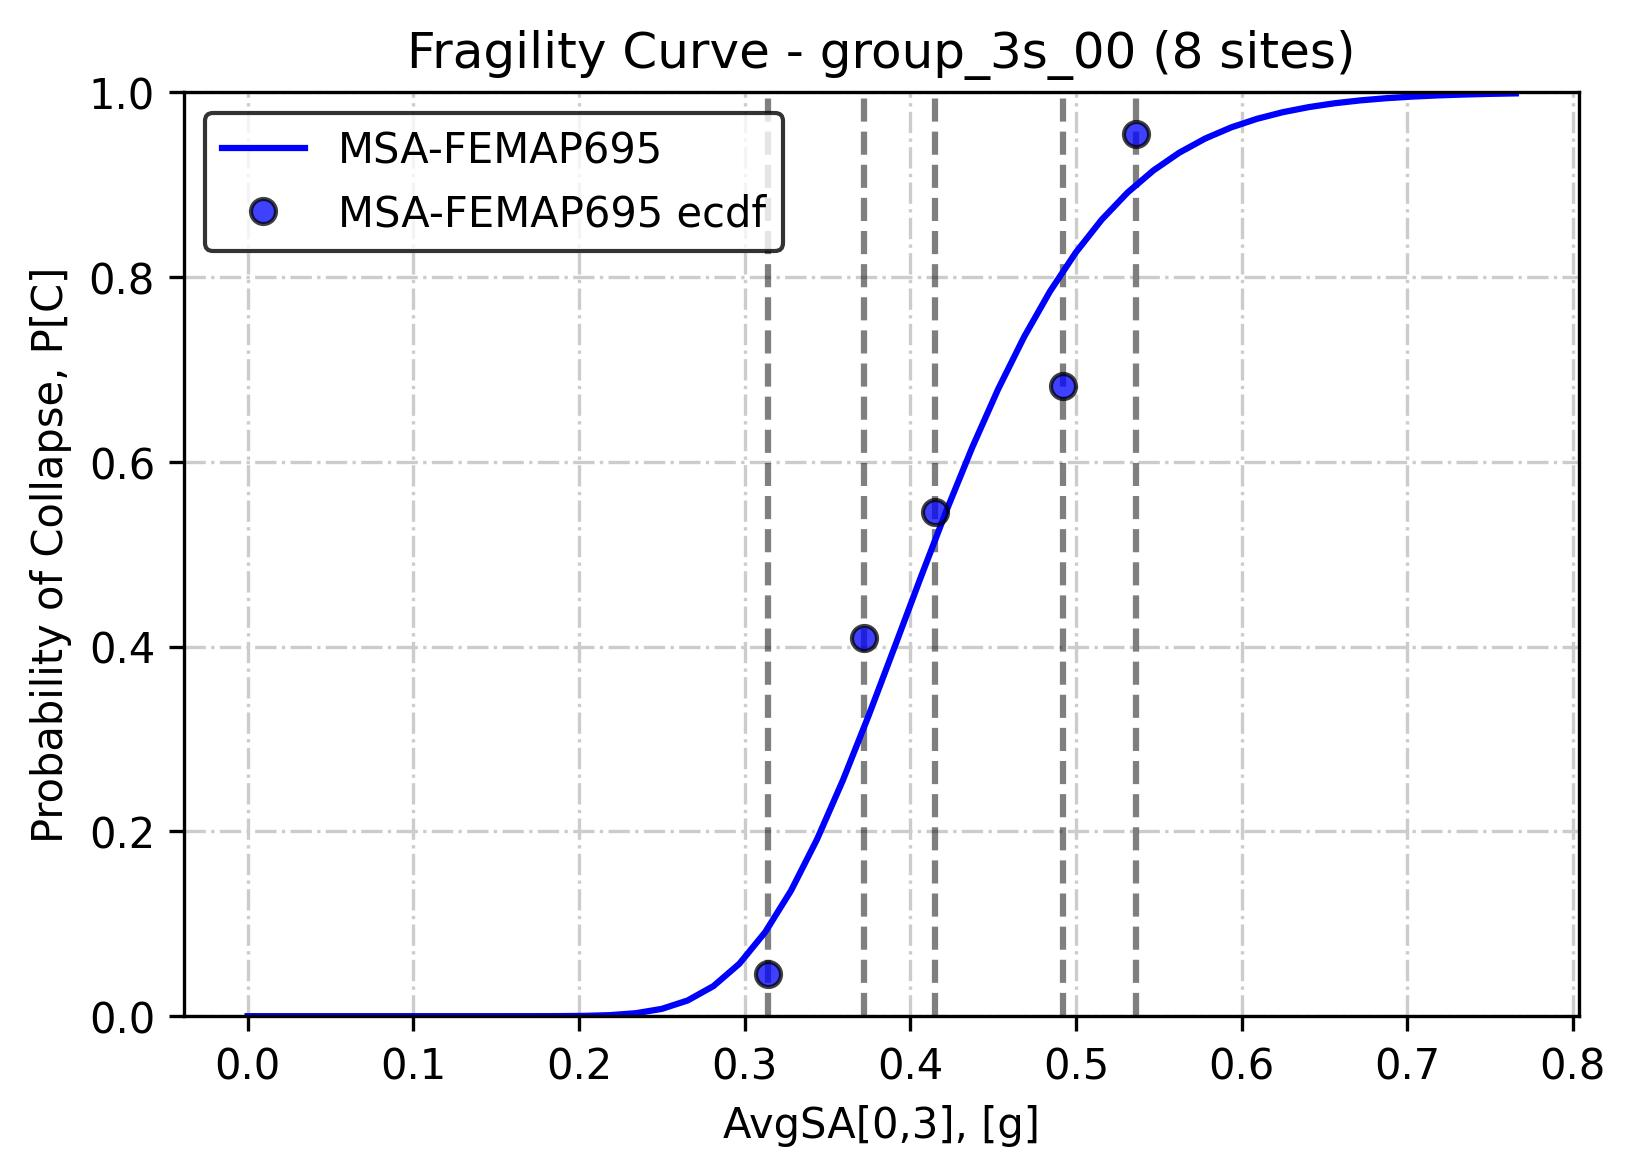

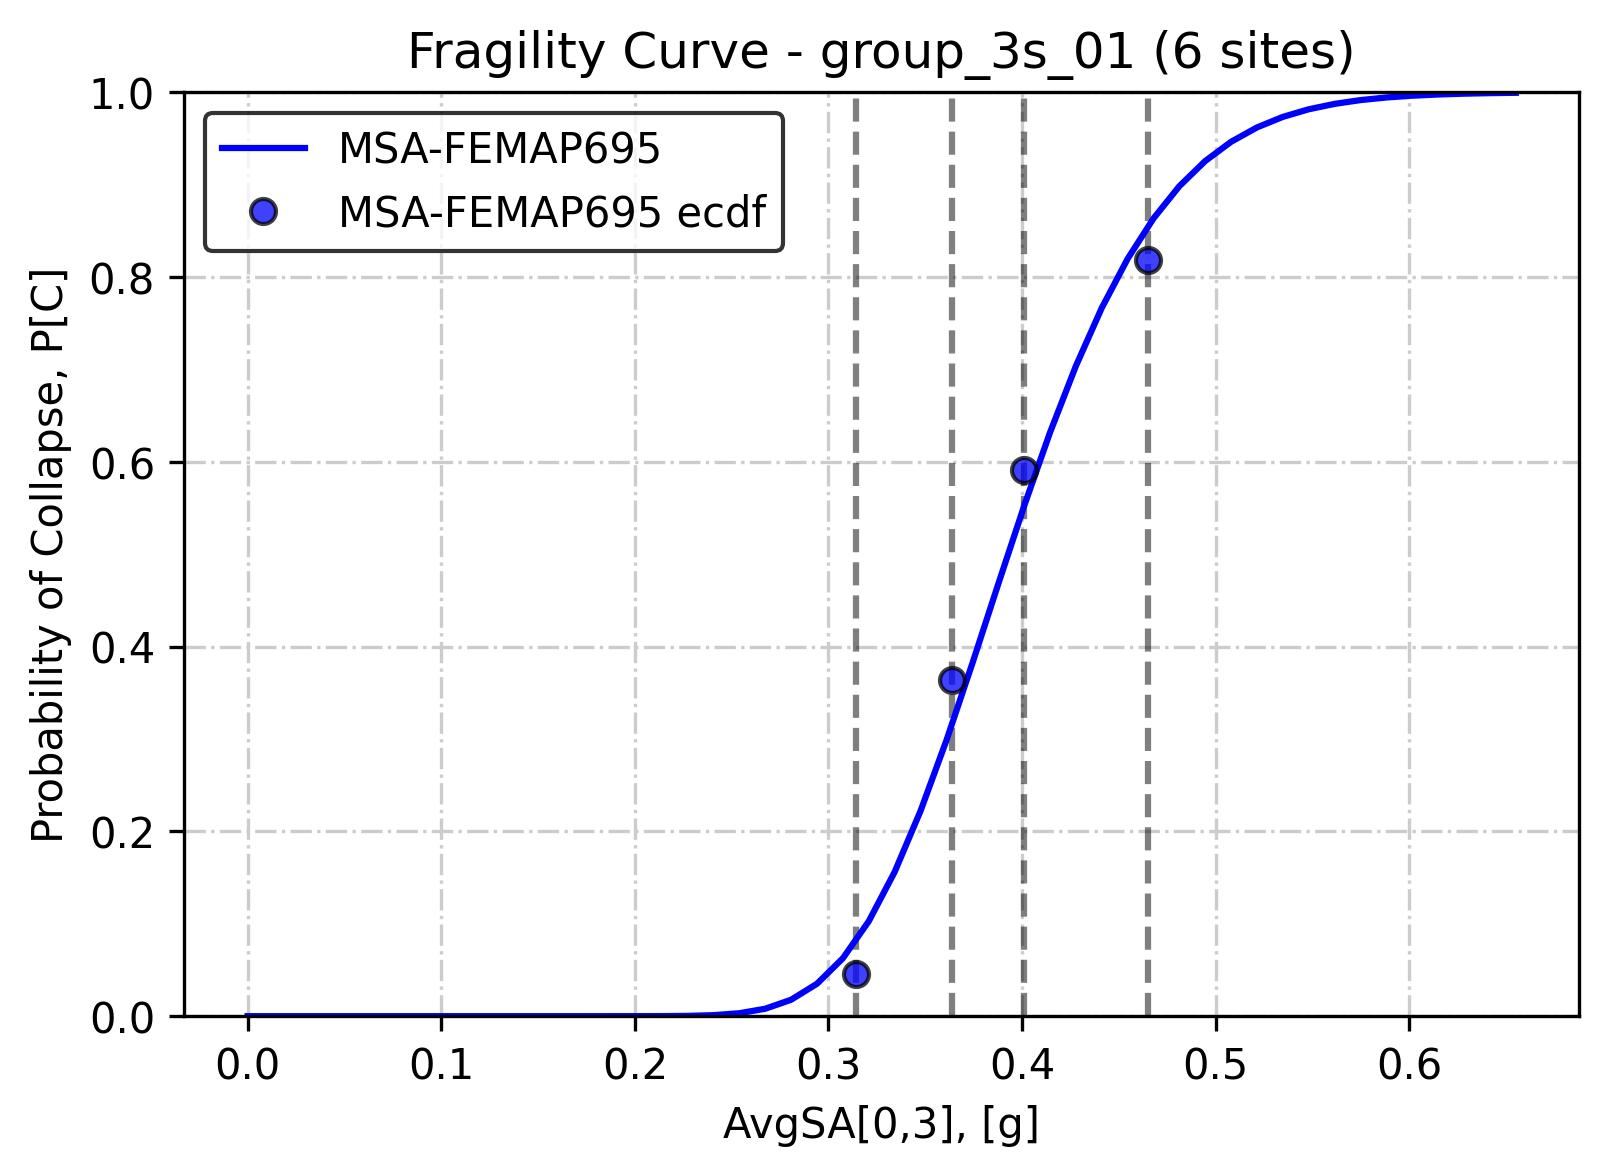

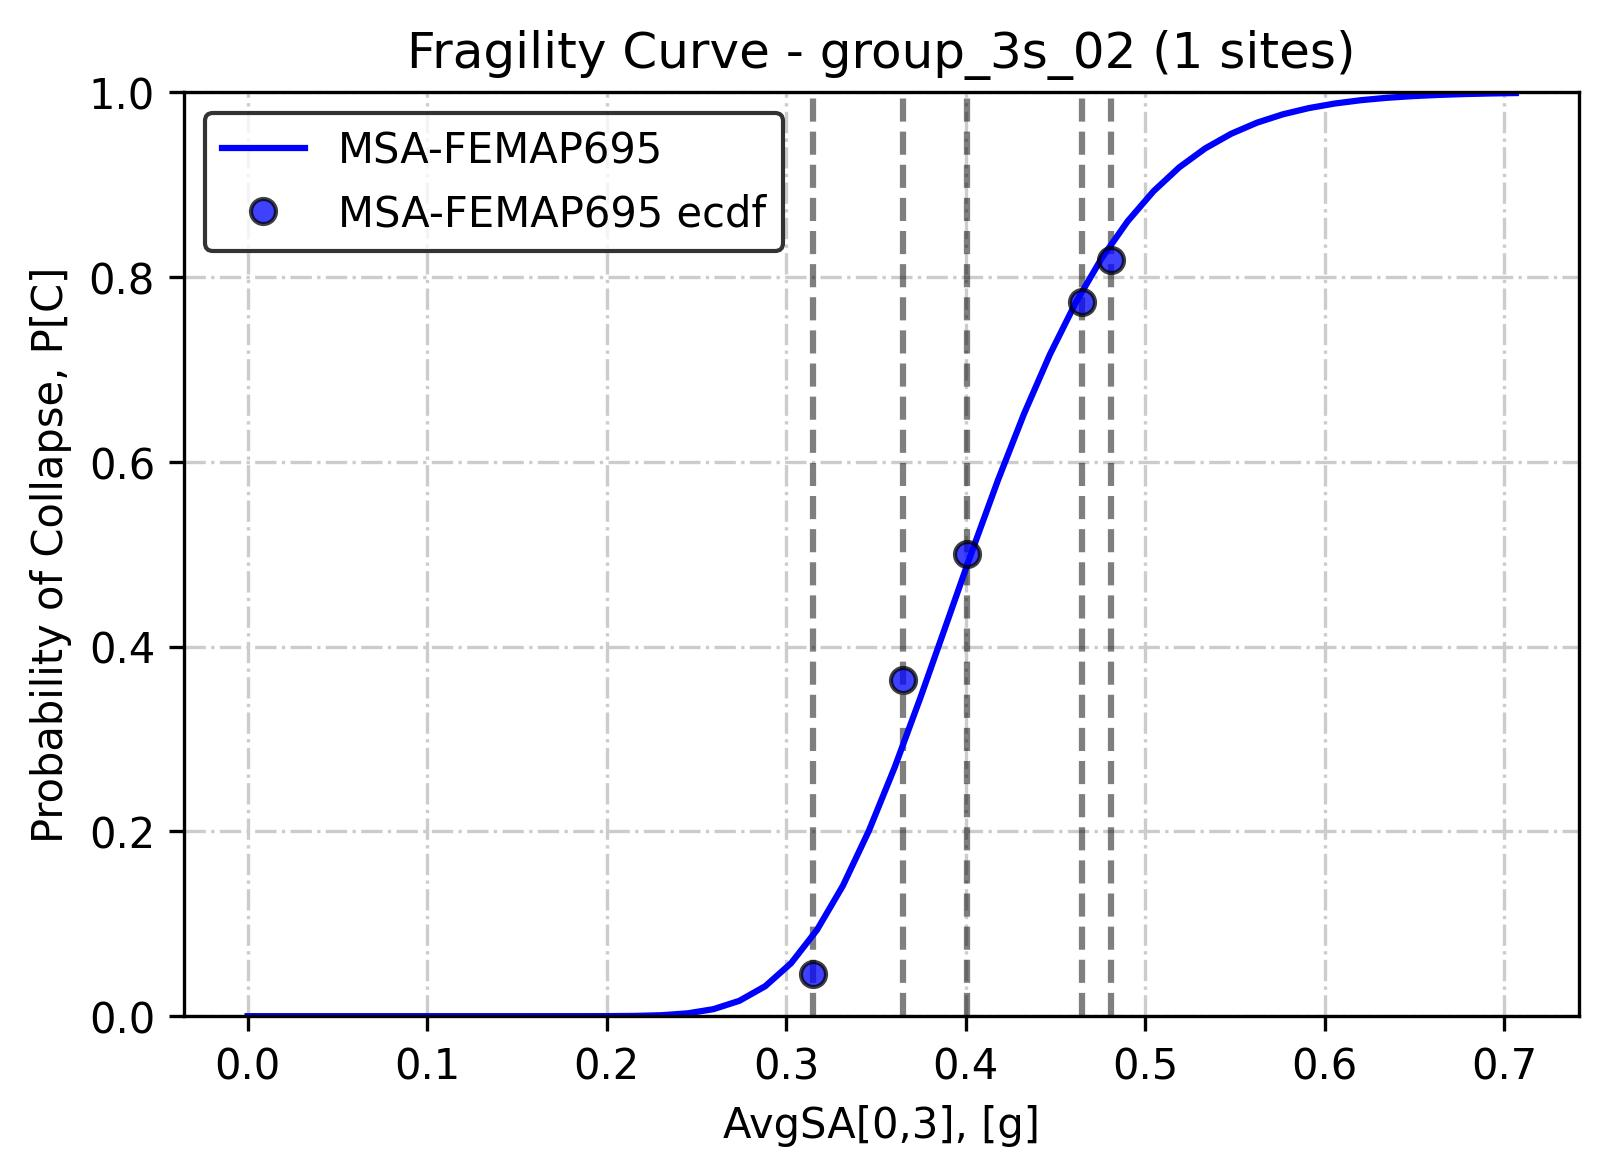

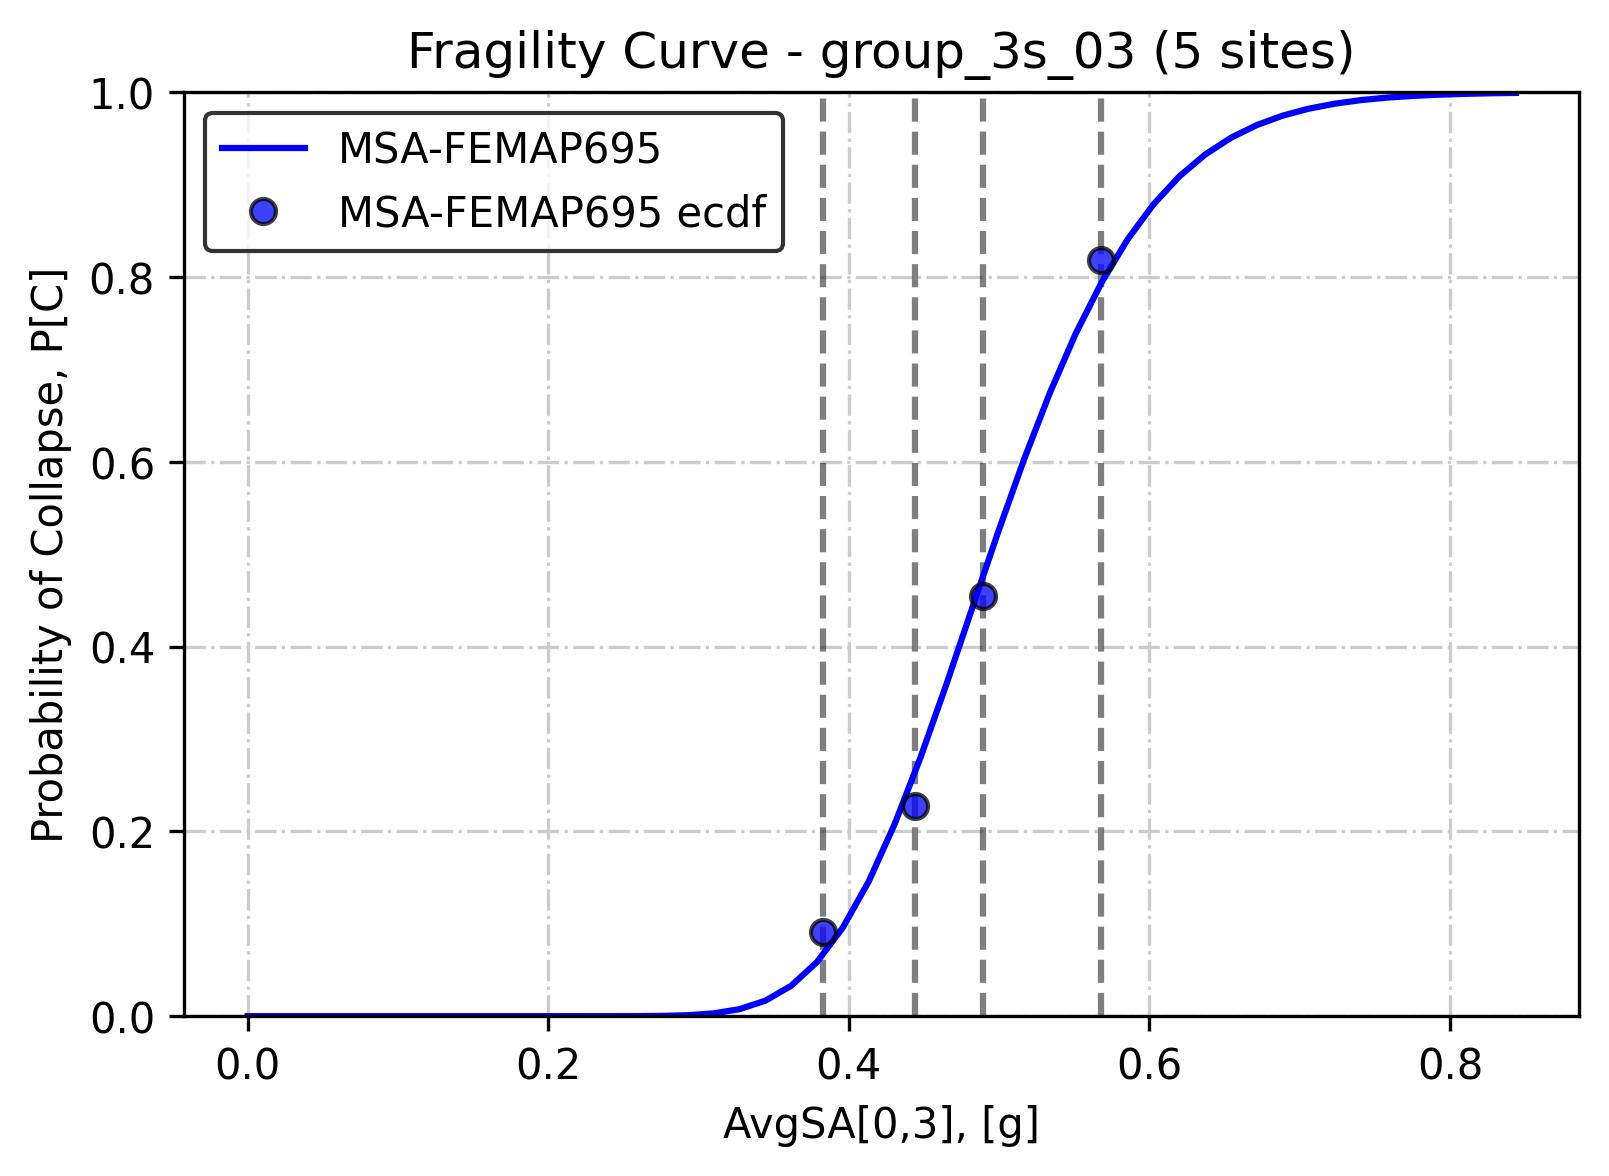

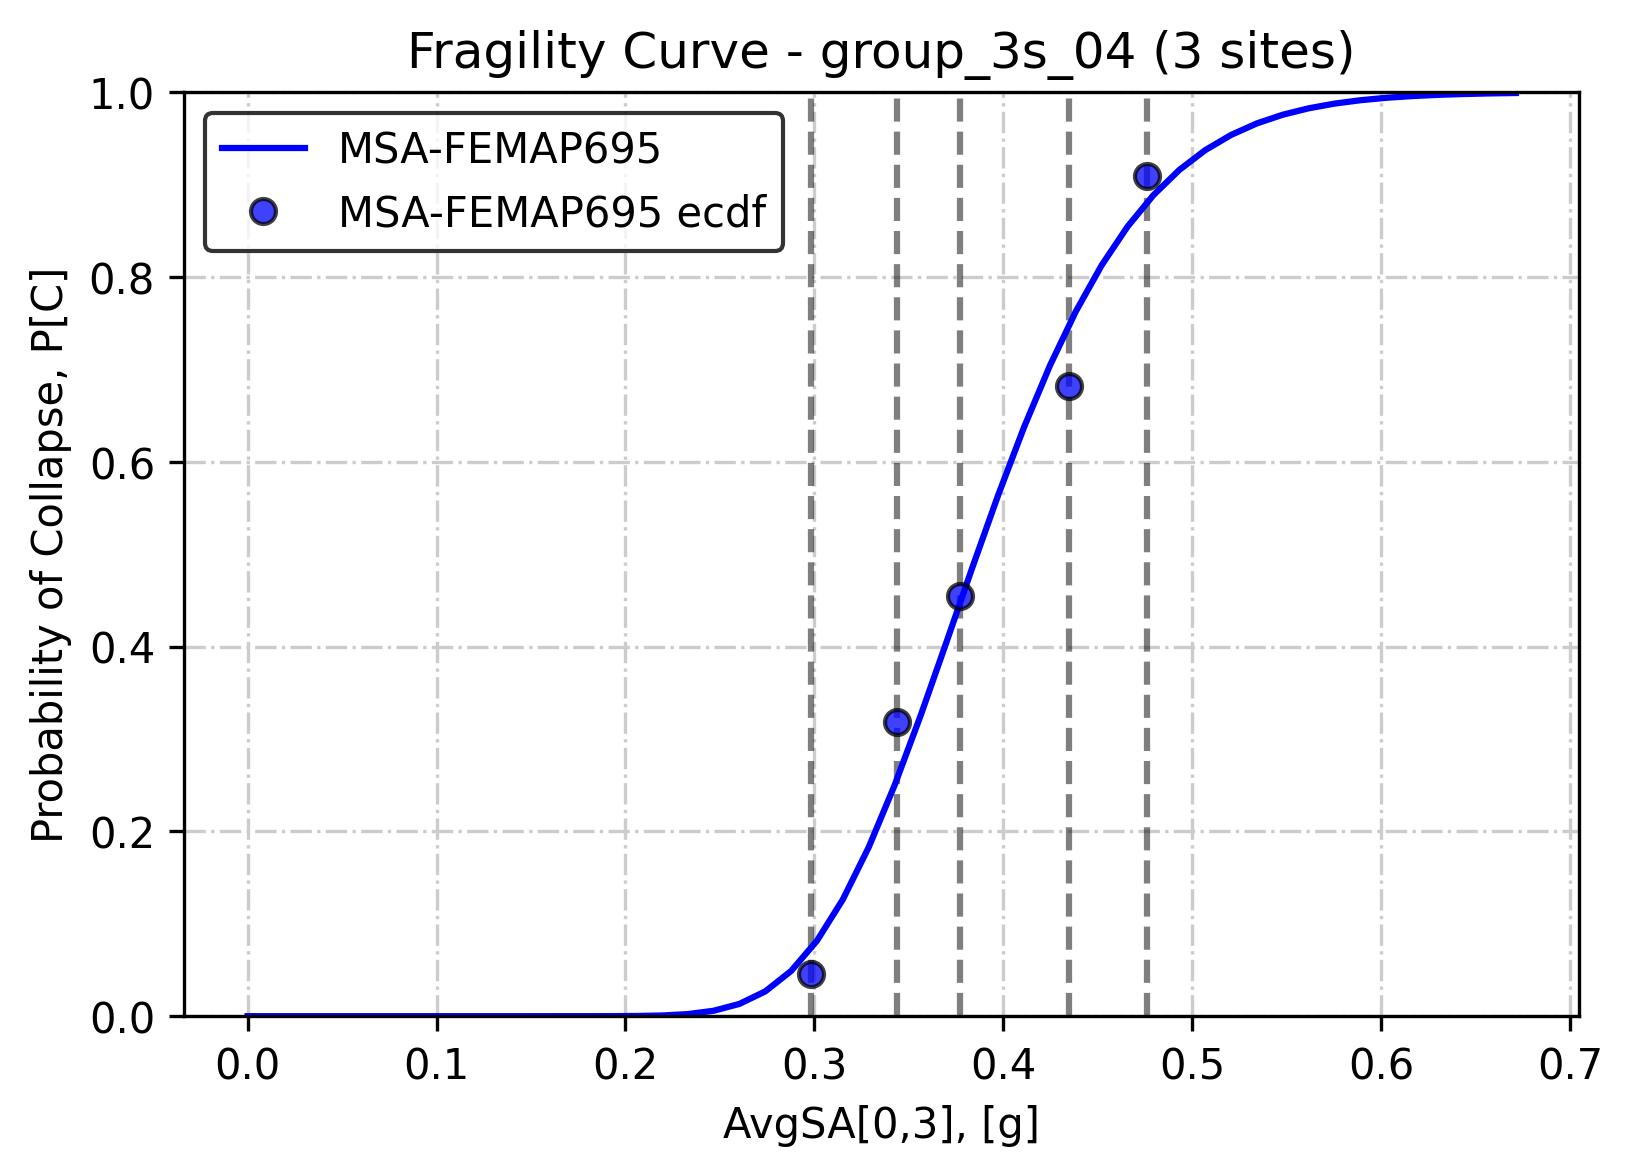

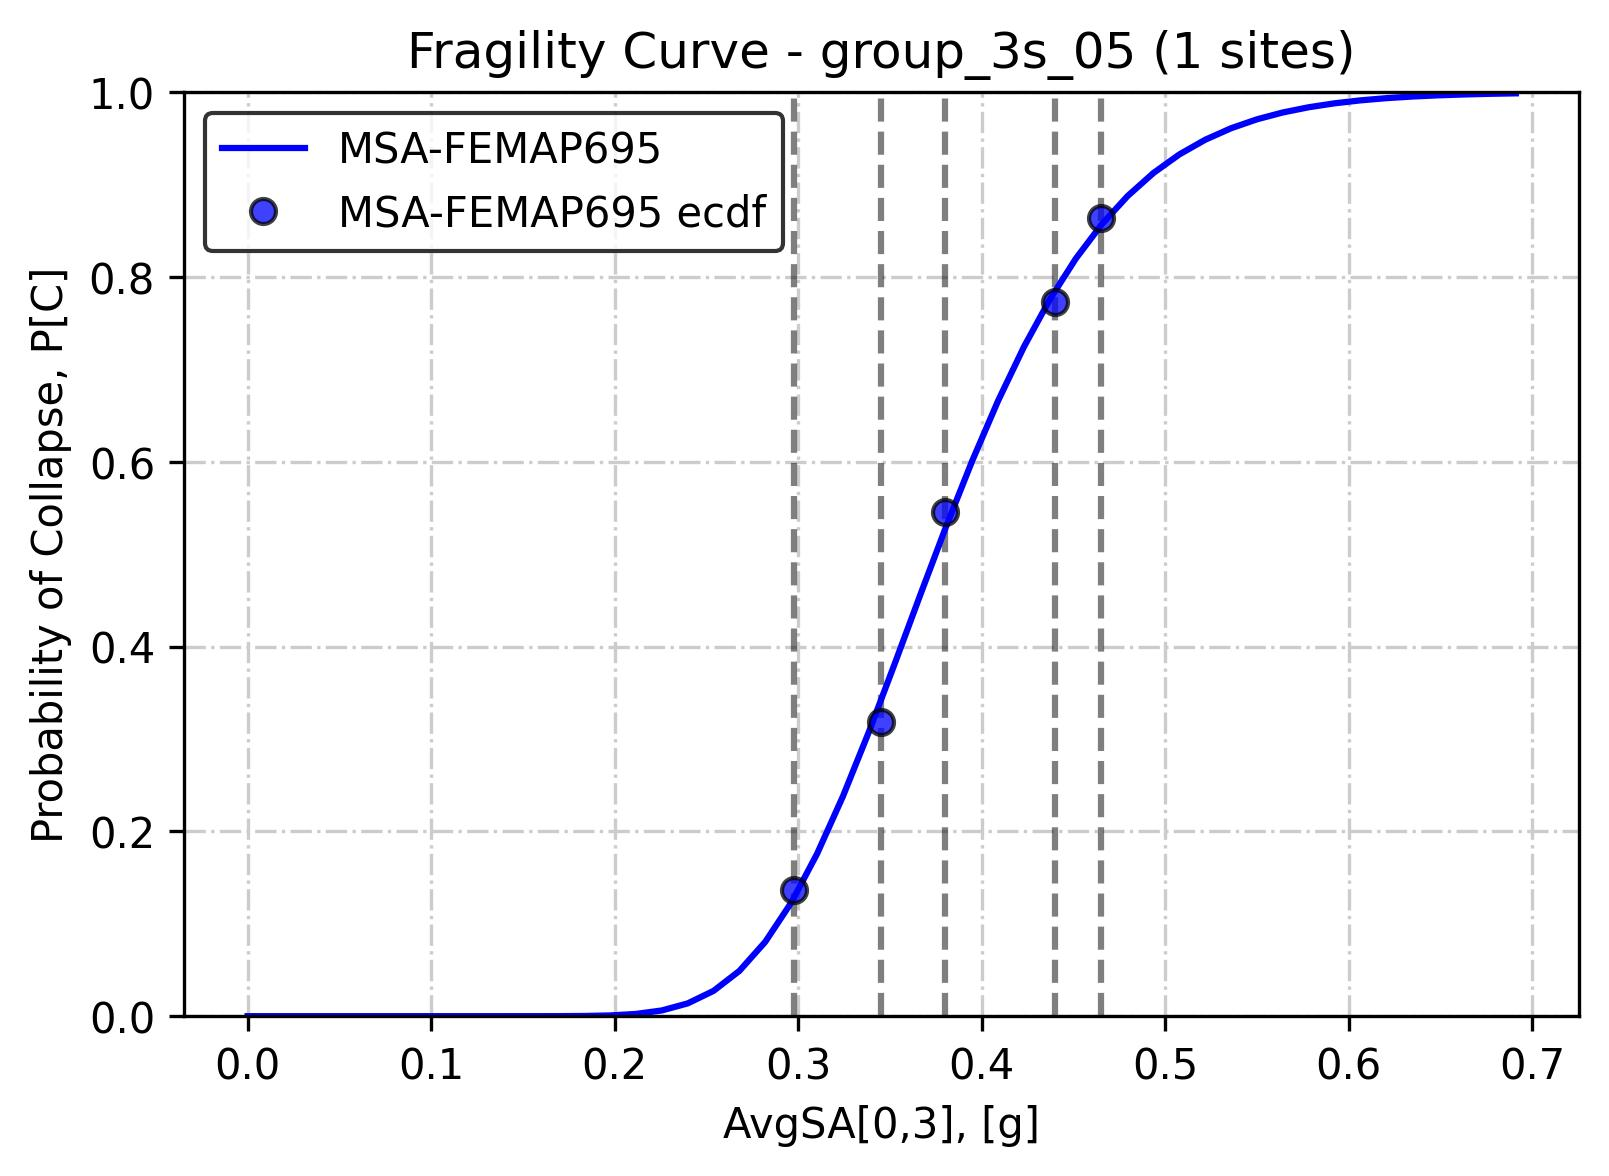

showing 6 of 25 figure(s); all of them are in C:\Users\clemettn\Documents\phd\results\07_group_msa_femap695


In [139]:
# Show the figures a few at a time, so a full 51-group run does not flood the notebook.
# Every figure is on disk under FIG_ROOT regardless of what is displayed here.
MAX_FIGS_SHOWN = 6

shown = sorted(group_results)[:MAX_FIGS_SHOWN]
for n, gid in shown:
    fp = plot_path(n, gid)
    if fp.is_file():
        display(Image(filename=str(fp), width=520))
print(f"showing {len(shown)} of {len(group_results)} figure(s); all of them are in "
      f"{FIG_ROOT}")

## 4. Fragility-curve definition check

Which groups the MSA-FEMAP695 stripes failed to bracket collapse for, reported separately
for each storey count. `054` aimed the four stripes at **P[C] = 0.15, 0.40, 0.60, 0.85**
by inverting the representative's `ida_femap695` AvgSA_03 fragility, so a failure here
means the MSA collapse capacity came out somewhere the IDA did not predict.

### Degenerate stripes do not count

A stripe where **no** record collapsed (P[C] = 0) or **every** record did (P[C] = 1) says
only that the collapse crossing is somewhere above or below it — it does not locate it, and
the binomial fit gets nothing from it beyond a bound. So a tail is reached only by a stripe
**strictly inside** `(0, PC_LOWER_THRESHOLD)` or `(PC_UPPER_THRESHOLD, 1)`:

- `needs_low` — no stripe has `0 < P[C] < 0.2`;
- `needs_high` — no stripe has `0.8 < P[C] < 1`.

A degenerate stripe sitting *alongside* an informative one is harmless; only a group whose
sole stripes past a threshold are degenerate now fails, and it gets another IML below. This
matters after a remediation round: an extra stripe aimed at P[C] = 0.85 is scaled well above
the group's previous top stripe and can come back 22/22, which the old max-P[C] test would
have accepted as done. With 22 records the attainable non-degenerate values run
1/22 = 0.045 … 21/22 = 0.955, so a qualifying stripe always exists. `n_zero` and `n_full`
count the degenerate stripes and travel into both summary CSVs and the remediation file.

Every group is still fanned out in §5 whatever the verdict, and the flag travels into both
summary CSVs.

### The remediation file

For each **failing tail** — a group short only at the top gets one entry, one short at both
ends gets two — an IML for the extra stripe is written to

`data_processed/09_structure_fragility_curves/wp1_design_groups/group_msa_femap695_additional_stripes.csv`

| column | |
|---|---|
| `group`, `storeys`, `group_id` | the design group; `group_id` is what `054` keys on |
| `n_sites`, `sites` | what the extra stripe buys |
| `tail` | `low` / `high` |
| `target_poc` | 0.15 or 0.85 — outside the 0.2 / 0.8 pass-fail band, so the new stripe has a buffer |
| `iml` | the IML [g], rounded to `IML_DECIMALS` (the resolution the stripe filename encodes) |
| `aim` | `fit` or `bisected` — how that IML was chosen, below |
| `pred_poc` | where the fitted curve expects the stripe to land; equal to `target_poc` for a `fit` aim |
| `msa_median`, `msa_dispersion`, `pc_min`, `pc_max` | the curve the suggestion came from |
| `n_zero`, `n_full` | how many of its stripes were degenerate — non-zero means the previous round's stripe landed at 0 or 100% and this one is aimed back inside |

**`fit`** — the IML the fitted MSA curve puts at `REMEDIATION_POCS`. The aim comes from the
**MSA** fit, not from the `ida_femap695` fragility `054` inverted for the original four
stripes: that fragility is precisely what mis-placed them, because the MSA came out with more
dispersion than the IDA predicted.

**`bisected`** — used where the tail failed because the stripe past the threshold came back
**degenerate**. The fit is a poor guide there: it was fitted through that stripe, and it is
what put the stripe out there in the first place. What the stripes *do* prove is that the
crossing lies between the degenerate stripe and the nearest informative stripe on the inside
of the threshold, so the new IML is the **geometric mean** of those two — halving that
interval in log-IML, the space the stripes are spaced in. It is only taken if the fitted
curve still puts it past 0.2 / 0.8; otherwise the stripe would land inside the band it has to
clear, and the `fit` aim is used instead.

This is not `060` §5. There is no hazard curve behind these stripes, so there are no reserve
stripes, no disaggregation grid and no ceiling — the record set is fixed and simply rescaled,
so any IML can be run. The loop is `061` → `054` → the MSA batch → `061`.

The file is **always rewritten**, with a header and no rows when every group is well defined,
so `054` can never act on a stale suggestion.

In [140]:
checks = []
for (n, gid), fc in sorted(group_results.items()):
    pc = fc["efc"][1, :]
    # Only a stripe strictly between 0 and 1 locates the collapse crossing; a 0/22 or 22/22
    # stripe merely bounds it, so it cannot satisfy a tail on its own.
    informative = (pc > 0) & (pc < 1)
    row = {
        "group": group_folder_name(n, gid),
        "storeys": n,
        "group_id": gid,
        "n_sites": len(members[(n, gid)]),
        "median": float(fc["median"]),
        "dispersion": float(fc["dispersion"]),
        "n_stripes": int(pc.size),
        "n_zero": int((pc <= 0).sum()),     # stripes where no record collapsed
        "n_full": int((pc >= 1).sum()),     # stripes where every record collapsed
        "pc_min": float(pc.min()),
        "pc_max": float(pc.max()),
        "needs_low": not bool((informative & (pc < PC_LOWER_THRESHOLD)).any()),
        "needs_high": not bool((informative & (pc > PC_UPPER_THRESHOLD)).any()),
        # what the old range-only test said, kept only so the report below can name the
        # groups whose verdict the degenerate-stripe rule changed
        "needs_low_range": bool(pc.min() >= PC_LOWER_THRESHOLD),
        "needs_high_range": bool(pc.max() <= PC_UPPER_THRESHOLD),
    }
    row["well_defined"] = not (row["needs_low"] or row["needs_high"])
    checks.append(row)

check = pd.DataFrame(checks)

print("Fragility-curve definition check")
print(f"  thresholds: some stripe must land in ({PC_UPPER_THRESHOLD:.2f}, 1) and some "
      f"stripe in (0, {PC_LOWER_THRESHOLD:.2f})")
print("  0% / 100% stripes are degenerate - they bound the crossing without locating it, "
      "so they satisfy neither tail")

for n in STOREYS:
    sub = check[check["storeys"] == n] if not check.empty else check
    print(f"\n{n}s groups - {len(sub)} assessed")
    if sub.empty:
        print("  no MSA-FEMAP695 fragility curves found.")
        continue
    lt = sub.loc[sub["needs_high"], "group"].tolist()
    gt = sub.loc[sub["needs_low"], "group"].tolist()
    print(f"  no stripe in ({PC_UPPER_THRESHOLD:.2f}, 1) (upper tail not reached) - "
          f"{len(lt)} group(s): {', '.join(lt) if lt else '-'}")
    print(f"  no stripe in (0, {PC_LOWER_THRESHOLD:.2f}) (lower tail not reached) - "
          f"{len(gt)} group(s): {', '.join(gt) if gt else '-'}")
    # Groups the old range-only test would have passed: their only stripe past a threshold
    # is a 0% or 100% one, so they now get another stripe instead of being called done.
    only_deg = sub.loc[(sub["needs_low"] & ~sub["needs_low_range"])
                       | (sub["needs_high"] & ~sub["needs_high_range"]), "group"].tolist()
    print(f"  degenerate stripes: {int((sub['n_zero'] > 0).sum())} group(s) with a 0% "
          f"stripe, {int((sub['n_full'] > 0).sum())} with a 100% stripe; "
          f"{len(only_deg)} fail a tail only because of one: "
          f"{', '.join(only_deg) if only_deg else '-'}")
    n_bad = int((~sub["well_defined"]).sum())
    n_sites_bad = int(sub.loc[~sub["well_defined"], "n_sites"].sum())
    print(f"  well defined: {len(sub) - n_bad}/{len(sub)}  "
          f"({n_bad} group(s) fail at least one threshold, covering "
          f"{n_sites_bad} site(s))")

Fragility-curve definition check
  thresholds: some stripe must land in (0.80, 1) and some stripe in (0, 0.20)
  0% / 100% stripes are degenerate - they bound the crossing without locating it, so they satisfy neither tail

3s groups - 25 assessed
  no stripe in (0.80, 1) (upper tail not reached) - 0 group(s): -
  no stripe in (0, 0.20) (lower tail not reached) - 0 group(s): -
  degenerate stripes: 1 group(s) with a 0% stripe, 1 with a 100% stripe; 0 fail a tail only because of one: -
  well defined: 25/25  (0 group(s) fail at least one threshold, covering 0 site(s))

5s groups - 0 assessed
  no MSA-FEMAP695 fragility curves found.


In [141]:
def remediation_iml(fc, tail, median, dispersion):
    """Where to put the extra stripe for a failing tail -> (iml, how, predicted P[C]).

    The default aim is the fitted MSA curve at REMEDIATION_POCS[tail] ("fit"), and it comes
    from the MSA fit rather than the ida_femap695 fragility nb 054 inverted for the original
    four stripes - that fragility is what mis-placed them.

    Where the tail failed because its stripe past the threshold is DEGENERATE, the fit is a
    poor guide: it was fitted through that stripe, and it already put the previous extra
    stripe out there. The collapse crossing is instead known to lie between the degenerate
    stripe and the nearest informative stripe on the inside of the threshold, so the aim is
    the geometric mean of those two ("bisected") - halving the interval in log-IML, the
    space the stripes are spaced in.

    The bisection is taken only if the fitted curve still puts it past the threshold
    (P[C] < PC_LOWER_THRESHOLD low, > PC_UPPER_THRESHOLD high). If it does not, the stripe
    would land inside the band it is meant to clear, so the fit aim is used instead.
    """
    iml, pc = fc["efc"][0, :], fc["efc"][1, :]
    informative = (pc > 0) & (pc < 1)
    fit = float(lognorm.ppf(REMEDIATION_POCS[tail], s=dispersion, scale=median))

    if tail == "low":
        deg, inner = iml[pc <= 0], iml[informative & (pc > PC_LOWER_THRESHOLD)]
        if deg.size and inner.size:
            cand = float(np.sqrt(deg.max() * inner.min()))
            if lognorm.cdf(cand, s=dispersion, scale=median) < PC_LOWER_THRESHOLD:
                return cand, "bisected"
    else:
        deg, inner = iml[pc >= 1], iml[informative & (pc < PC_UPPER_THRESHOLD)]
        if deg.size and inner.size:
            cand = float(np.sqrt(deg.min() * inner.max()))
            if lognorm.cdf(cand, s=dispersion, scale=median) > PC_UPPER_THRESHOLD:
                return cand, "bisected"
    return fit, "fit"


# One row per failing tail.
extra_rows = []
for row in (check[~check["well_defined"]].itertuples() if not check.empty else []):
    fc = group_results[(row.storeys, row.group_id)]
    for tail, needs in (("low", row.needs_low), ("high", row.needs_high)):
        if not needs:
            continue
        iml, how = remediation_iml(fc, tail, row.median, row.dispersion)
        iml = round(iml, IML_DECIMALS)
        extra_rows.append({
            "group": row.group,
            "storeys": row.storeys,
            "group_id": row.group_id,
            "n_sites": row.n_sites,
            "sites": " ".join(str(s) for s in members[(row.storeys, row.group_id)]),
            "tail": tail,
            "target_poc": REMEDIATION_POCS[tail],
            "iml": iml,
            "aim": how,
            # where the fitted curve expects the new stripe to land. Equal to target_poc for
            # a "fit" aim; for a "bisected" one it only has to clear the 0.2 / 0.8 band.
            "pred_poc": round(float(lognorm.cdf(iml, s=row.dispersion, scale=row.median)), 3),
            "msa_median": row.median,
            "msa_dispersion": row.dispersion,
            "pc_min": row.pc_min,
            "pc_max": row.pc_max,
            "n_zero": row.n_zero,
            "n_full": row.n_full,
        })

COLUMNS = ["group", "storeys", "group_id", "n_sites", "sites", "tail", "target_poc",
           "iml", "aim", "pred_poc", "msa_median", "msa_dispersion", "pc_min", "pc_max",
           "n_zero", "n_full"]
additional = pd.DataFrame(extra_rows, columns=COLUMNS)
if not additional.empty:
    additional = additional.sort_values(["storeys", "group_id", "tail"])

# Written even when empty (header only), so nb 054 cannot act on a stale suggestion.
ADDITIONAL_STRIPES_CSV.parent.mkdir(parents=True, exist_ok=True)
additional.to_csv(ADDITIONAL_STRIPES_CSV, index=False)

if check.empty:
    print("no groups processed - nothing to check")
    print(f"wrote an empty {ADDITIONAL_STRIPES_CSV.name}")
elif additional.empty:
    print("every group's stripes bracket collapse - no extra stripes needed")
    print(f"wrote an empty {ADDITIONAL_STRIPES_CSV.name}")
else:
    with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
        print(additional.to_string(index=False))
    n_groups = additional["group"].nunique()
    print(f"\nwrote {len(additional)} extra stripe(s) over {n_groups} group(s) to "
          f"{ADDITIONAL_STRIPES_CSV}")
    n_bis = int((additional["aim"] == "bisected").sum())
    if n_bis:
        print(f"{n_bis} of them are aimed by BISECTION - the previous round's stripe came "
              f"back degenerate there, so the new IML halves the interval between it and "
              f"the nearest informative stripe instead of trusting the fit.")

    print("\nACTION REQUIRED by User:")
    print("  1. re-run nb 054, which reads this file and writes the extra stripe")
    print("     selections alongside its four (and refreshes the group folders on D:);")
    print("  2. re-run the MSA-FEMAP695 batch (msa_AvgSA03_femap695.py). The runner's")
    print("     resume = True reuses every (stripe, record) pair already analysed, so only")
    print("     the new stripes actually run;")
    print("  3. re-run THIS notebook to refit the affected groups and fan them back out.")

every group's stripes bracket collapse - no extra stripes needed
wrote an empty group_msa_femap695_additional_stripes.csv


## 5. Fan the group fragility out to its member sites

Each group's fragility is copied to **every** member site as
`site_{ii}/{tag}_msa_femap695_collapsefragility_AvgSA_03.json`, next to the site's `msa`
and `ida_femap695` files, so anything downstream stays on per-site paths and never has to
learn about groups.

The per-site manifest fingerprints the **group fragility JSON**, not the source on `D:` —
a site file is stale exactly when its group's fragility changed, which also means the
fan-out works with the analysis drive detached.

In [142]:
def site_fragility_path(n: int, site: int) -> Path:
    tag = structure_tag(n, site)
    return (OUT_ROOT / f"site_{int(site)}"
            / f"{tag}_{MSA_TAG}_collapsefragility_{GM_SET}.json")


site_results: dict[tuple[int, int], dict] = {}          # (storeys, site) -> fragility
site_group: dict[tuple[int, int], tuple[int, int]] = {}
fanout_status = {"cached": 0, "computed": 0}

if not FANOUT_TO_SITES:
    print("FANOUT_TO_SITES is False - only the group-level files were written")
else:
    for (n, gid), fc in sorted(group_results.items()):
        name = group_folder_name(n, gid)
        src = group_fragility_path(n, gid)
        for site in members[(n, gid)]:
            fp = site_fragility_path(n, site)
            fp.parent.mkdir(parents=True, exist_ok=True)
            out, status = json_load_or_compute(
                fp,
                fingerprint(group_fragility=src, group=name,
                            site=int(site), storeys=int(n)),
                lambda fc=fc: fc,
                force=FORCE_RECOMPUTE,
                input_paths={"group_fragility": src},
            )
            fanout_status[status] += 1
            site_results[(n, site)] = {k: np.array(v) if isinstance(v, list) else v
                                       for k, v in out.items()}
            site_group[(n, site)] = (n, gid)
        print(f"[fanout] {name} -> {len(members[(n, gid)])} site(s): "
              f"{fmt_sites(members[(n, gid)])}")

    print(f"\n{len(site_results)} structure(s) written to {OUT_ROOT} "
          f"({fanout_status['computed']} file(s) written, "
          f"{fanout_status['cached']} already current)")

[fanout] group_3s_00 -> 8 site(s): 0, 4, 8, 19, 25, 26, 27, 29
[fanout] group_3s_01 -> 6 site(s): 1, 2, 5, 6, 16, 23
[fanout] group_3s_02 -> 1 site(s): 3
[fanout] group_3s_03 -> 5 site(s): 7, 10, 11, 18, 24
[fanout] group_3s_04 -> 3 site(s): 9, 20, 22
[fanout] group_3s_05 -> 1 site(s): 12
[fanout] group_3s_06 -> 2 site(s): 13, 28
[fanout] group_3s_07 -> 1 site(s): 14
[fanout] group_3s_08 -> 1 site(s): 15
[fanout] group_3s_09 -> 2 site(s): 17, 21
[fanout] group_3s_10 -> 1 site(s): 30
[fanout] group_3s_11 -> 4 site(s): 31, 34, 43, 59
[fanout] group_3s_12 -> 4 site(s): 32, 33, 36, 50
[fanout] group_3s_13 -> 3 site(s): 35, 39, 58
[fanout] group_3s_14 -> 1 site(s): 37
[fanout] group_3s_15 -> 1 site(s): 38
[fanout] group_3s_16 -> 1 site(s): 40
[fanout] group_3s_17 -> 3 site(s): 41, 54, 57
[fanout] group_3s_18 -> 2 site(s): 42, 56
[fanout] group_3s_19 -> 3 site(s): 44, 46, 49
[fanout] group_3s_20 -> 2 site(s): 45, 52
[fanout] group_3s_21 -> 1 site(s): 47
[fanout] group_3s_22 -> 2 site(s): 48,

### Coverage

Which (storey, site) structures ended up with an MSA-FEMAP695 fragility. Every site of
every storey count in `STOREYS` should appear exactly once; sites whose group has no MSA
run yet are listed as missing.

In [143]:
cov_rows = []
for n in STOREYS:
    all_sites = sorted(groups_df.loc[groups_df["storeys"] == n, "site"].astype(int))
    got = [s for s in all_sites if (n, s) in site_results]
    cov_rows.append({"storeys": n, "sites": len(all_sites), "with_fragility": len(got),
                     "missing": len(all_sites) - len(got),
                     "groups_processed": sum(1 for k in group_results if k[0] == n),
                     "groups_total": int((groups["storeys"] == n).sum())})

coverage = pd.DataFrame(cov_rows)
print(coverage.to_string(index=False))
for n in STOREYS:
    miss = [s for s in sorted(groups_df.loc[groups_df["storeys"] == n, "site"].astype(int))
            if (n, s) not in site_results]
    if miss:
        print(f"{n}s missing sites: {fmt_sites(miss)}")

 storeys  sites  with_fragility  missing  groups_processed  groups_total
       3     60              60        0                25            25
       5     60               0       60                 0            26
5s missing sites: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59


## 7. Summary tables

Both carry the collapse median in **g**, the dimensionless lognormal $\beta$, the P[C]
range the stripes actually spanned, and the well-definedness flag from §4:

- **group level** — one row per design group, with its member sites, to
  `wp1_design_groups/group_msa_femap695_collapsefragility_summary.csv`;
- **site level** — one row per structure, to
  `wp1_casestudy_sites/site_msa_femap695_collapsefragility_summary.csv`.

In [144]:
if check.empty:
    print("no groups processed - no group summary written")
else:
    group_summary = (check
                     .assign(sites=[" ".join(str(s) for s in members[(int(r.storeys),
                                                                     int(r.group_id))])
                                    for r in check.itertuples()])
                     .loc[:, ["group", "storeys", "n_sites", "sites", "median",
                              "dispersion", "pc_min", "pc_max", "n_zero", "n_full",
                              "well_defined"]]
                     .set_index("group")
                     .sort_values(["storeys", "median"]))
    with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
        print(group_summary.to_string())
    GROUP_SUMMARY_CSV.parent.mkdir(parents=True, exist_ok=True)
    group_summary.to_csv(GROUP_SUMMARY_CSV)
    print(f"\nwrote {GROUP_SUMMARY_CSV}")

             storeys  n_sites                 sites  median  dispersion  pc_min  pc_max  n_zero  n_full  well_defined
group                                                                                                                
group_3s_06        3        2                 13 28   0.375       0.215   0.136   0.864       0       0          True
group_3s_05        3        1                    12   0.375       0.203   0.136   0.864       0       0          True
group_3s_07        3        1                    14   0.375       0.204   0.136   0.864       0       0          True
group_3s_08        3        1                    15   0.384       0.175   0.045   0.818       0       0          True
group_3s_04        3        3               9 20 22   0.386       0.178   0.045   0.909       0       0          True
group_3s_01        3        6         1 2 5 6 16 23   0.393       0.160   0.045   0.818       0       0          True
group_3s_02        3        1                     3   0.

In [145]:
flags = check.set_index(["storeys", "group_id"])["well_defined"] if not check.empty else {}

site_rows = {}
for (n, site), fc in sorted(site_results.items()):
    key = site_group[(n, site)]
    pc = fc["efc"][1, :]
    site_rows[structure_tag(n, site)] = {
        "storeys": n,
        "site": site,
        "group": group_folder_name(*key),
        "median": float(fc["median"]),
        "dispersion": float(fc["dispersion"]),
        "pc_min": float(pc.min()),
        "pc_max": float(pc.max()),
        "n_zero": int((pc <= 0).sum()),
        "n_full": int((pc >= 1).sum()),
        "well_defined": bool(flags[key]),
    }

site_summary = pd.DataFrame.from_dict(site_rows, orient="index")
if site_summary.empty:
    print("no structures written - no site summary written")
else:
    site_summary.index.name = "structure"
    site_summary = site_summary.sort_values(["storeys", "site"])
    with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
        print(site_summary.to_string())
    SITE_SUMMARY_CSV.parent.mkdir(parents=True, exist_ok=True)
    site_summary.to_csv(SITE_SUMMARY_CSV)
    print(f"\nwrote {SITE_SUMMARY_CSV}")

                   storeys  site        group  median  dispersion  pc_min  pc_max  n_zero  n_full  well_defined
structure                                                                                                      
3s_cbf_dc2_site0         3     0  group_3s_00   0.412       0.207   0.045   0.955       0       0          True
3s_cbf_dc2_site1         3     1  group_3s_01   0.393       0.160   0.045   0.818       0       0          True
3s_cbf_dc2_site2         3     2  group_3s_01   0.393       0.160   0.045   0.818       0       0          True
3s_cbf_dc2_site3         3     3  group_3s_02   0.403       0.181   0.045   0.818       0       0          True
3s_cbf_dc2_site4         3     4  group_3s_00   0.412       0.207   0.045   0.955       0       0          True
3s_cbf_dc2_site5         3     5  group_3s_01   0.393       0.160   0.045   0.818       0       0          True
3s_cbf_dc2_site6         3     6  group_3s_01   0.393       0.160   0.045   0.818       0       0       

## 8. Per-record collapse outcomes

The fragilities above are a two-number summary of what happened to 22 records at each
stripe; the summary CSVs keep only the *fraction* that collapsed. A **non-parametric**
bootstrap (nb 070) resamples records, so it needs to know *which* records collapsed - the
MSA analogue of the per-record collapse capacities nb 053 writes for the IDA arm.

This section writes them out, one **(group, stripe) x record** table:

| file | content |
|---|---|
| `group_msa_femap695_collapse_flags_AvgSA_03.csv` | `1` if that record collapsed at that stripe, `0` if it did not, `NaN` if it was not run |

Rows carry a `(group, stripe_iml)` MultiIndex - `stripe_iml` is the stripe's
`intensity_level` in g, the same number as `efc[0]` in the fragility. Columns are the
**record tag**, the `record_{tag}_log.json` suffix, labelled `"0"` ... `"21"` exactly as in
nb 053's capacity tables, so column `7` is the same physical record in both arms and one set
of bootstrap resamples applies to either.

Each group's outcomes are also cached beside its fragility as
`group_{n}s_{gid}_msa_femap695_collapseflags_AvgSA_03.json`, fingerprinted on the stripe
logs they were read from, so the table rebuilds with the analysis drive detached.

| # | question | assumption taken | if it should change |
|---|---|---|---|
| 8 | Where do the per-record outcomes come from? | The **stripe logs** on the analysis drive (`stripe_*/msa_log_stripe_*.json`), read with `standes.analysis.msa.collect_stripe_logs`. Not `msa_log.json` - `process_msa_results` does not write one. | - |
| 9 | Does record tag `k` mean the same record here as in the IDA tables? | **Yes, and it is checked.** Each record log carries its `record_name`; the check below requires the tag -> name map to be identical at every stripe of every group *and* to match the sorted `fema_p695_*.json` listing the IDA indexed on. A mismatch would silently corrupt every bootstrap replicate, so it is verified rather than assumed. | - |
| 10 | A stripe missing some records? | **Reported, not an error**: those cells are `NaN`, and the fraction-collapsed check below is taken over the records actually run - consistent with how section 3 tolerates a group that is still running. | - |


In [ ]:
def stripe_log_paths(n: int, gid: int) -> dict[str, Path]:
    """The per-stripe logs of one group's MSA run, keyed by stripe folder suffix."""
    paths = {}
    for folder in sorted(group_msa_folder(n, gid).glob("stripe_*")):
        tag = folder.name.split("_", 1)[-1]
        log_fp = folder / f"msa_log_stripe_{tag}.json"
        if log_fp.is_file():
            paths[tag] = log_fp
    return paths


def collapse_flags_path(n: int, gid: int) -> Path:
    """The processed copy of a group's per-record collapse outcomes."""
    name = group_folder_name(n, gid)
    return GROUP_OUT_ROOT / name / f"{name}_{MSA_TAG}_collapseflags_{GM_SET}.json"


def read_collapse_flags(n: int, gid: int) -> dict:
    """{stripe_iml: {record_tag: collapsed}} for one group, straight off the stripe logs.

    ``collect_stripe_logs`` already orders the stripes by ascending intensity, and each
    stripe log's ``records`` maps the record tag to that record's log - which carries both
    the collapse flag and the record name. The name is kept alongside so section 8b can
    verify the tags mean the same records everywhere. The IML is keyed by ``repr`` so the
    float survives the JSON round-trip exactly and still matches ``efc[0]``.
    """
    collated = collect_stripe_logs(group_msa_folder(n, gid))
    stripes = {}
    for key, log in collated.items():
        if not key.startswith("stripe_"):
            continue
        stripes[repr(float(log["intensity_level"]))] = {
            "collapsed": {tag: bool(r["collapsed"]) for tag, r in log["records"].items()},
            "record_names": {tag: r["record_name"] for tag, r in log["records"].items()},
        }
    return stripes


group_flags: dict[tuple[int, int], dict] = {}
flag_statuses = {"computed": [], "cached": [], "offline": [], "skipped": []}

for (n, gid) in sorted(group_results):
    save_fp = collapse_flags_path(n, gid)

    if ANALYSIS_OK:
        logs = stripe_log_paths(n, gid)
        if not logs:
            if STRICT:
                raise FileNotFoundError(f"{group_folder_name(n, gid)}: no stripe logs under "
                                        f"{group_msa_folder(n, gid)}")
            flag_statuses["skipped"].append((n, gid))
            continue

        # One named input per stripe log, so the fingerprint pins exactly which stripes
        # these outcomes came from and re-running a single stripe invalidates the cache.
        # Fingerprinting the run FOLDER would not do: cache_utils only hashes bytes for a
        # path that is a file, so a directory silently degrades to hashing its name.
        inputs = {f"stripe_{tag}": fp for tag, fp in logs.items()}
        save_fp.parent.mkdir(parents=True, exist_ok=True)
        flags_raw, status = json_load_or_compute(
            save_fp,
            fingerprint(**inputs),
            lambda n=n, gid=gid: read_collapse_flags(n, gid),
            force=FORCE_RECOMPUTE,
            input_paths=inputs,
        )
    else:
        # Offline: reuse the cached copy as-is, exactly as section 3 does.
        if not save_fp.is_file():
            flag_statuses["skipped"].append((n, gid))
            continue
        with open(save_fp, "r") as file:
            flags_raw = json.load(file)
        status = "offline"

    flag_statuses[status].append((n, gid))
    group_flags[(n, gid)] = flags_raw

print("\n" + "   ".join(f"[{name}] {len(v)}" for name, v in flag_statuses.items()))
print(f"{len(group_flags)}/{len(group_results)} group(s) with per-record outcomes")
if flag_statuses["skipped"]:
    print("  skipped (no stripe logs available):")
    for n in STOREYS:
        sk = [gid for ns, gid in flag_statuses["skipped"] if ns == n]
        if sk:
            print(f"    {n}s - {len(sk)}: "
                  f"{', '.join(group_folder_name(n, g) for g in sk)}")


In [ ]:
# --- check 1: a record tag means the same record everywhere -------------------------
# The bootstrap applies ONE set of resampled record tags to every structure and to both
# arms, so this has to hold before the table is worth anything.
expected_names = {str(i): f"{stem}.json"
                  for i, stem in enumerate(femap695_record_tags(FEMAP695_RECORDS))}

tag_mismatches = []
for (n, gid), stripes in sorted(group_flags.items()):
    for iml, s in stripes.items():
        for tag, name in s["record_names"].items():
            if expected_names.get(tag) != name:
                tag_mismatches.append((group_folder_name(n, gid), iml, tag, name,
                                       expected_names.get(tag, "-")))

print(f"record-tag check: {len(expected_names)} records expected from {FEMAP695_RECORDS.name}")
if tag_mismatches:
    print(f"  !! {len(tag_mismatches)} tag/name mismatch(es) - the MSA record tags do NOT "
          "line up with the IDA tables, so the two arms cannot share bootstrap resamples:")
    for row in tag_mismatches[:10]:
        print(f"     {row[0]} iml={row[1]} tag={row[2]}: {row[3]} (expected {row[4]})")
else:
    print("  ok - every stripe of every group maps tag k to the k-th sorted record, "
          "the same convention nb 053's capacity tables use")

# --- assemble the (group, stripe_iml) x record table --------------------------------
# Columns are the union of tags seen anywhere, so a stripe missing a record shows NaN
# rather than shifting its neighbours (nb 053 section 8 reindexes the same way).
RECORD_TAGS = sorted({t for s in group_flags.values()
                      for v in s.values() for t in v["collapsed"]})

frames = {}
for (n, gid), stripes in sorted(group_flags.items()):
    rows = {float(iml): s["collapsed"] for iml, s in stripes.items()}
    df = pd.DataFrame.from_dict(rows, orient="index").reindex(columns=RECORD_TAGS)
    frames[group_folder_name(n, gid)] = df.sort_index()

if not frames:
    print("\nno groups with per-record outcomes - no collapse-flag table written")
else:
    collapse_flags = pd.concat(frames.values(), keys=frames.keys())
    collapse_flags.index.names = ["group", "stripe_iml"]
    collapse_flags.columns.name = "record"
    collapse_flags = collapse_flags.astype("Int8")

    # --- check 2: the flags must reproduce the empirical curve they came from --------
    # efc[1] is (records collapsed)/(records run) at each stripe. Recomputing it from the
    # flags is an end-to-end test that no stripe was dropped, duplicated or misaligned.
    deviations = []
    for (n, gid), fc in sorted(group_results.items()):
        if (n, gid) not in group_flags:
            continue
        sub = collapse_flags.loc[group_folder_name(n, gid)]
        pc_from_flags = sub.sum(axis=1) / sub.count(axis=1)
        for iml, pc in zip(fc["efc"][0, :], fc["efc"][1, :]):
            match = pc_from_flags.index[np.isclose(pc_from_flags.index, float(iml))]
            if not len(match):
                deviations.append((group_folder_name(n, gid), float(iml), np.nan))
                continue
            deviations.append((group_folder_name(n, gid), float(iml),
                               abs(float(pc_from_flags[match[0]]) - float(pc))))

    dev = pd.DataFrame(deviations, columns=["group", "iml", "abs_dev"])
    missing = dev[dev["abs_dev"].isna()]
    worst = dev["abs_dev"].max()
    print(f"\nfraction-collapsed check over {len(dev)} (group, stripe) pairs: "
          f"max |flags - efc| = {0.0 if pd.isna(worst) else worst:.2e}")
    if len(missing):
        print(f"  !! {len(missing)} stripe(s) in a fitted curve have no stripe log:")
        for r in missing.head(10).itertuples():
            print(f"     {r.group} iml={r.iml:.3f}")
    if not pd.isna(worst) and worst > 0:
        print("  !! the flags do not reproduce the fitted empirical curve")

    COLLAPSE_FLAGS_CSV.parent.mkdir(parents=True, exist_ok=True)
    collapse_flags.to_csv(COLLAPSE_FLAGS_CSV)
    n_groups = collapse_flags.index.get_level_values("group").nunique()
    print(f"\nwrote {COLLAPSE_FLAGS_CSV}  ({n_groups} groups, "
          f"{collapse_flags.shape[0]} stripes x {collapse_flags.shape[1]} records)")

    # A short row means that stripe is missing records - reported per stripe, not raised.
    short = collapse_flags.count(axis=1)
    short = short[short < len(RECORD_TAGS)]
    if len(short):
        print(f"  {len(short)} stripe(s) with fewer than {len(RECORD_TAGS)} records:")
        for (g, iml), k in short.items():
            print(f"    {g} iml={iml:.3f}: {k} records")

    display(collapse_flags.head())
